 PREDICTIVE TASK-KONDWANI MTONYA

In [1]:
import pandas as pd

df = pd.read_csv('/content/Wholesale customers data.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

First 5 rows of the DataFrame:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergent

In [2]:
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.000000    3127.750000   1533.000000   2153.000000   
50%      1.000000    3.000000    8504.000000   3627.000000   4755.500000   
75%      2.000000    3.000000   16933.750000   7190.250000  10655.750000   
max      2.000000    3.000000  112151.000000  73498.000000  92780.000000   

             Frozen  Detergents_Paper    Delicassen  
count    440.000000        440.000000    440.000000  
mean    3071.931818       2881.493182   1524.870455  
std     4854.673333       4767.854448   2820.105937  
min       25.000000          3.000000      3.000000  
25%      742.250000 

In [3]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


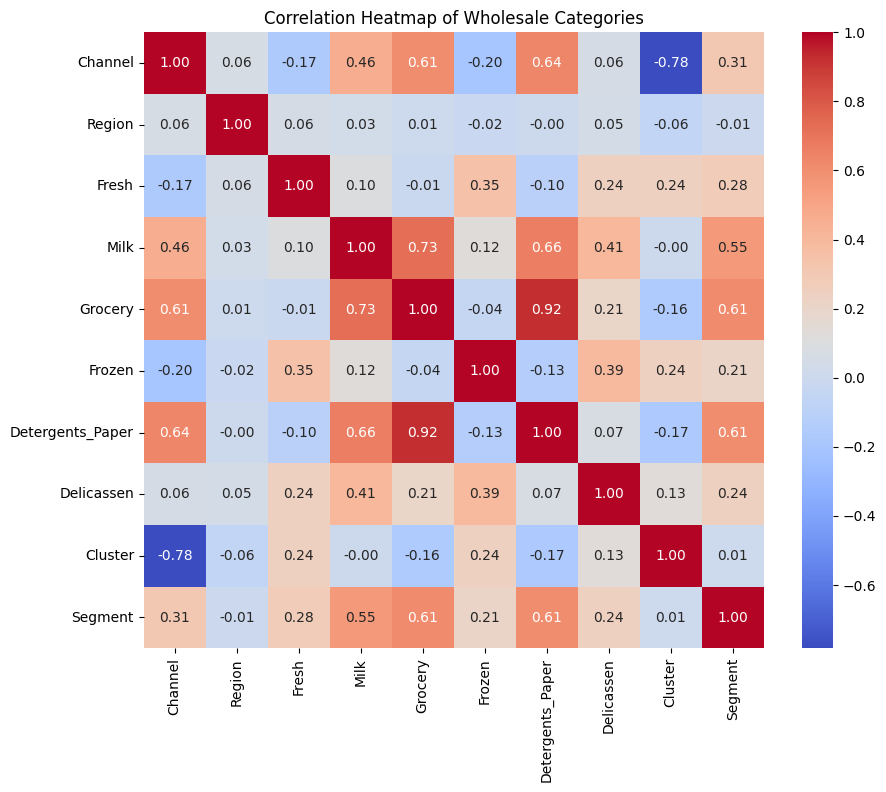

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Wholesale Categories')
plt.show()

In [27]:
X = df.drop(['Channel', 'Region'], axis=1)
y = df['Channel']

In [29]:
import numpy as np

X_log = np.log1p(X)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y, test_size=0.25, random_state=42, stratify=y
)

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [33]:
y_pred = clf.predict(X_test_scaled)

print("\n--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Horeca', 'Retail']))


--- Model Performance ---
Accuracy Score: 0.9909

Classification Report:
              precision    recall  f1-score   support

      Horeca       0.99      1.00      0.99        75
      Retail       1.00      0.97      0.99        35

    accuracy                           0.99       110
   macro avg       0.99      0.99      0.99       110
weighted avg       0.99      0.99      0.99       110



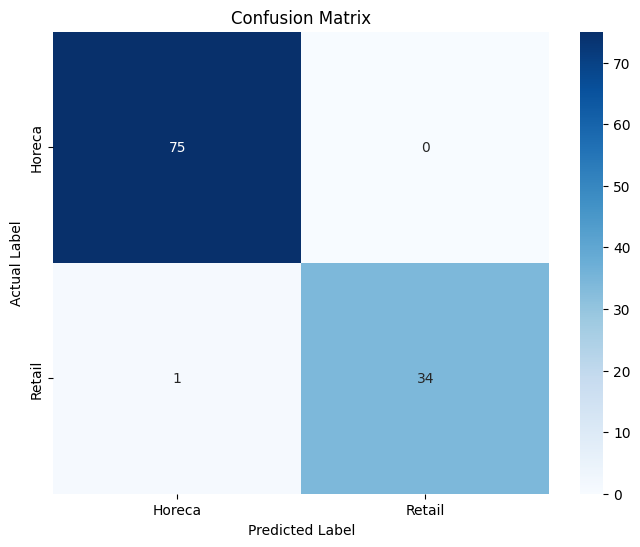

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Horeca', 'Retail'], yticklabels=['Horeca', 'Retail'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

/tmp/ipython-input-3354530489.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


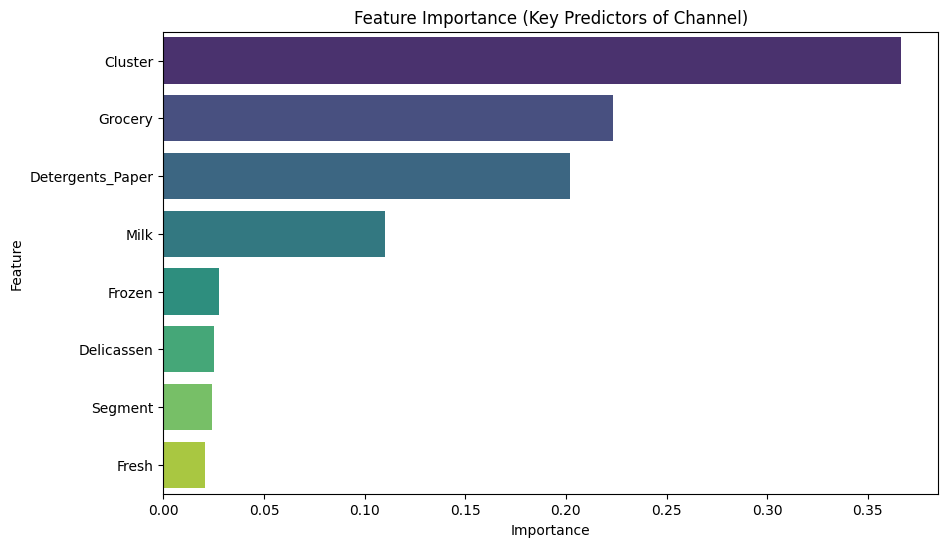


--- Key Predictors ---
            Feature  Importance
6           Cluster    0.366623
2           Grocery    0.223235
4  Detergents_Paper    0.202232
1              Milk    0.110079
3            Frozen    0.027519
5        Delicassen    0.025097
7           Segment    0.024310
0             Fresh    0.020905


In [36]:
importances = clf.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance (Key Predictors of Channel)')
plt.show()

print("\n--- Key Predictors ---")
print(feat_imp_df)

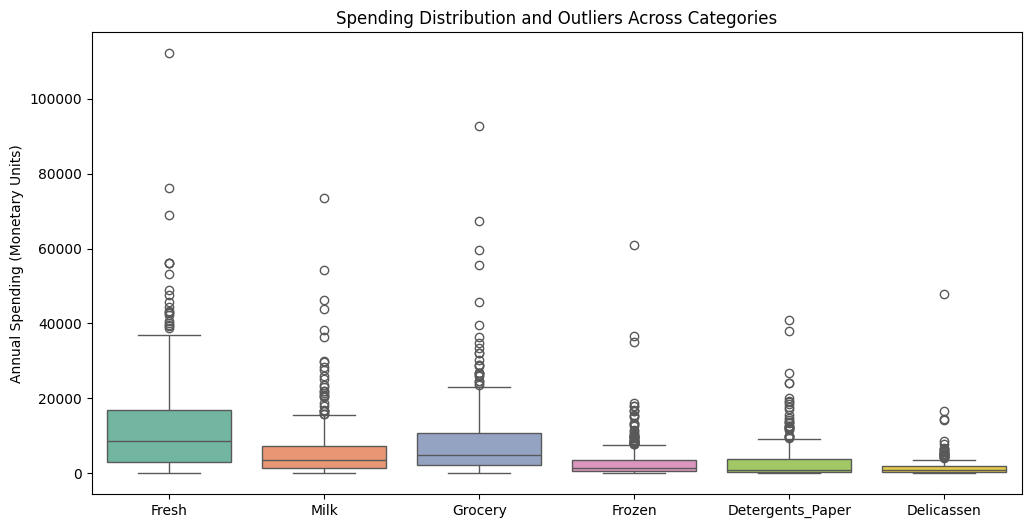

In [38]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[spending_features], palette="Set2")
plt.title('Spending Distribution and Outliers Across Categories')
plt.ylabel('Annual Spending (Monetary Units)')
plt.show()

/tmp/ipython-input-1776095083.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_labels, y=channel_counts.values, ax=ax[0], palette='viridis')
/tmp/ipython-input-1776095083.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_labels, y=region_counts.values, ax=ax[1], palette='magma')


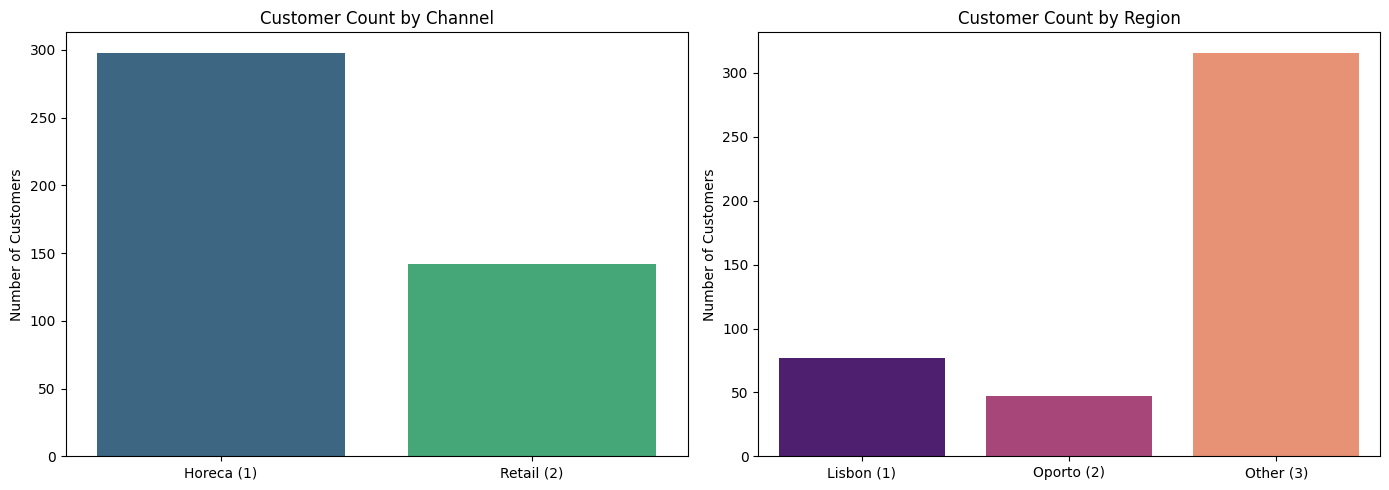

In [41]:
# 5. CHANNEL AND REGION DISTRIBUTIONS (Bar Charts)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Customer count per Channel
channel_counts = df['Channel'].value_counts().sort_index()
channel_labels = ['Horeca (1)', 'Retail (2)']
sns.barplot(x=channel_labels, y=channel_counts.values, ax=ax[0], palette='viridis')
ax[0].set_title('Customer Count by Channel')
ax[0].set_ylabel('Number of Customers')

# Customer count per Region
region_counts = df['Region'].value_counts().sort_index()
region_labels = ['Lisbon (1)', 'Oporto (2)', 'Other (3)']
sns.barplot(x=region_labels, y=region_counts.values, ax=ax[1], palette='magma')
ax[1].set_title('Customer Count by Region')
ax[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

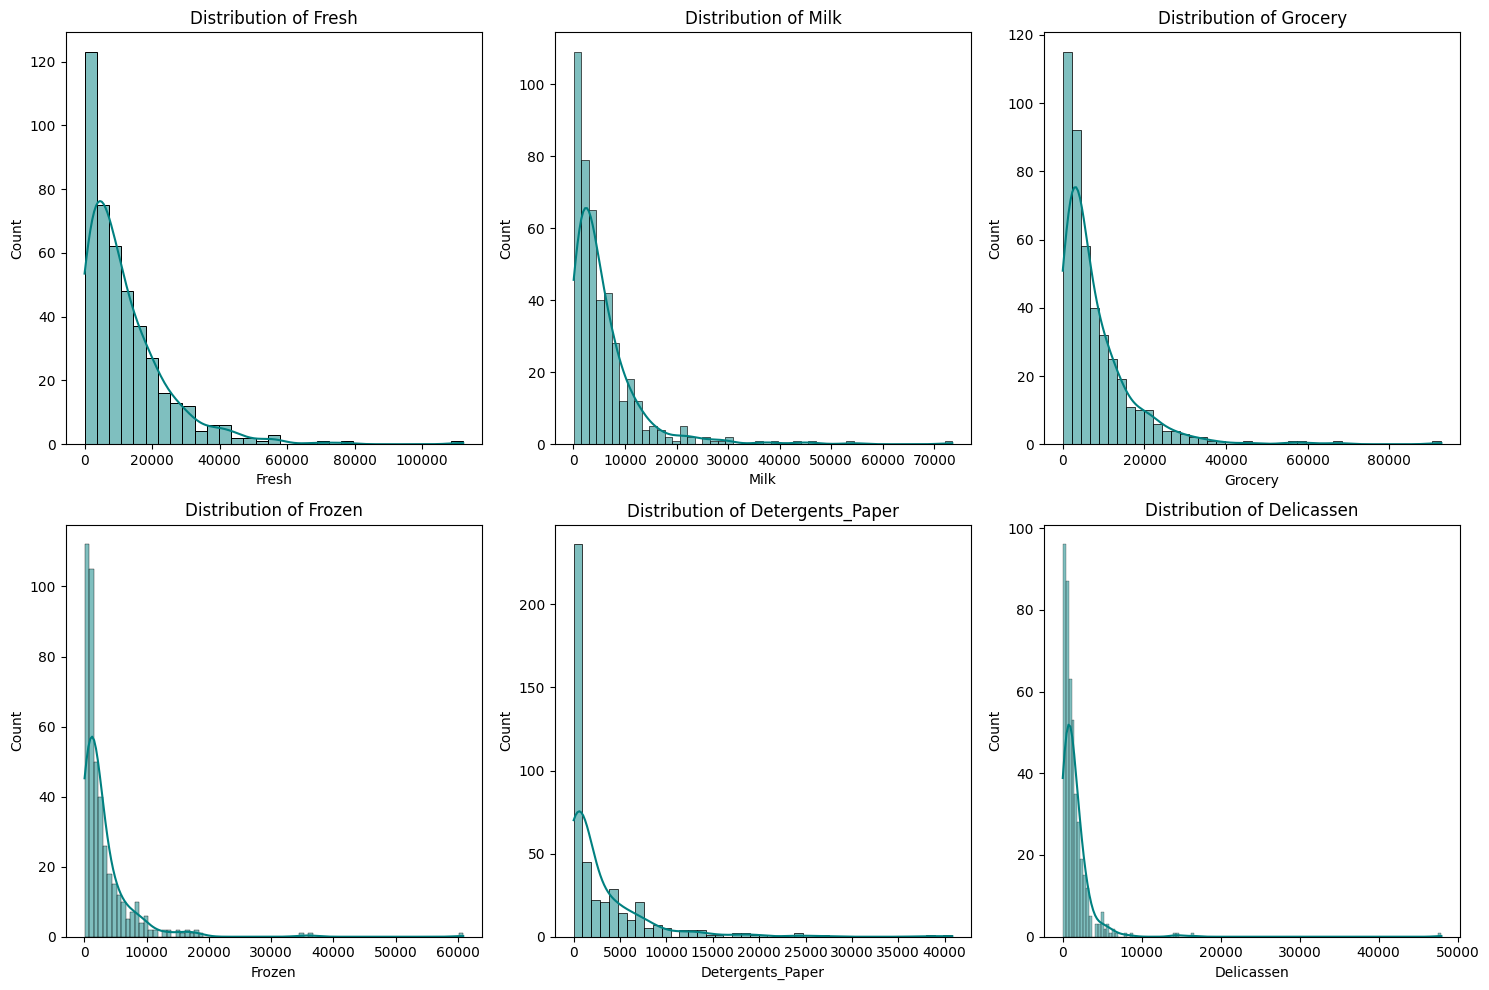

In [44]:
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

plt.figure(figsize=(15, 10))
for i, col in enumerate(spending_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()